# Methods Deep Dive: CAAFE, LLM-FE, OpenFE & Malmus

> ⚠️ **LLM cells require an API key.** Non-LLM methods (OpenFE) work without one.
>
> This notebook covers the 4 non-MALMAS feature engineering methods available in Feature Forge.
> For the MALMAS multi-agent pipeline, see [02_pipeline_deep_dive.ipynb](./02_pipeline_deep_dive.ipynb).

In [1]:
import os, pathlib, sys, warnings
warnings.filterwarnings('ignore')
os.environ.setdefault('FF_LOG_LEVEL', 'warning')
sys.path.insert(0, str(pathlib.Path('.').resolve()))

import matplotlib.pyplot as plt
import pandas as pd
import time

from _utils import get_llm_client, make_sample_data
from feature_forge.config import Settings
from feature_forge.evaluation import CVEvaluator

X_train, X_test, y_train, y_test = make_sample_data(n_samples=300, n_features=8, n_informative=5)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

llm = get_llm_client()
if llm is None: print('No LLM key. LLM cells will be skipped.')

evaluator = CVEvaluator()
baseline_auc = evaluator.evaluate_baseline(X_train, y_train)
print(f'Baseline AUC (no FE): {baseline_auc:.4f}')

Train: (210, 8), Test: (90, 8)


Baseline AUC (no FE): 0.9124


## 1. Method Overview

| Method | LLM Required | Approach | Key Strength | Source |
|--------|-------------|----------|-------------|--------|
| **MALMAS** | Yes | Multi-agent with memory & router | Best for complex datasets | arXiv 2604.20261 |
| **CAAFE** | Yes | Iterative prompting with dataset context | Domain knowledge injection | NeurIPS 2023 |
| **LLM-FE** | Yes | Evolutionary program search | Iterative improvement via feedback | TMLR 2026 |
| **OpenFE** | No | Tree-based operator expansion | Strongest non-LLM baseline | ICML 2023 |
| **Malmus** | Yes | Structured JSON output | Reliable parsing, no markdown stripping | Feature Forge original |

In [2]:
from feature_forge.methods import MethodRegistry
from feature_forge.methods.base import MethodProtocol

methods = MethodRegistry.get_builtin_methods()
print(f'{len(methods)} registered methods:\n')
for name, cls in methods.items():
    print(f'  {name}: {cls.__name__}')

5 registered methods:

  malmas: MALMASMethod
  openfe: OpenFEMethod
  caafe: CAAFEMethod
  llmfe: LLMFEMethod
  malmus: MalmusMethod


## 2. OpenFE — Tree-Based Feature Generation

**Paper:** Zhang et al., "OpenFE: Automated Feature Generation with Expert-level Performance", ICML 2023.
arXiv: [2211.12507](https://arxiv.org/abs/2211.12507) | GitHub: [IIIS-Li-Group/OpenFE](https://github.com/IIIS-Li-Group/OpenFE)

### How it works (no LLM):

1. **Expansion**: Applies 23 operators (arithmetic, GroupBy, Combine) to base features up to second-order
2. **FeatureBoost**: Incremental GBDT training on top of base predictions (no retraining from scratch)
3. **Two-Stage Pruning**: Successive halving → Mean Decrease in Impurity (MDI)
4. **Benchmark**: Beat 99.3% of Kaggle teams on IEEE-CIS Fraud Detection

### Feature Forge wrapper

`OpenFEMethod` wraps the `openfe` package with best-effort artifact extraction. Since OpenFE doesn't generate code, artifacts are operator names and importance scores.

In [3]:
from feature_forge.methods.openfe.method import OpenFEMethod

try:
    ofe = OpenFEMethod(metric='auc')
    t0 = time.perf_counter()
    ofe.fit(X_train, y_train)
    ofe_latency = time.perf_counter() - t0
    X_ofe = ofe.transform(X_train)

    gain = evaluator.evaluate_feature(X_train, y_train, X_ofe, baseline_score=baseline_auc)
    print(f'OpenFE: {X_ofe.shape[1]} features, gain={gain:+.4f}, latency={ofe_latency:.1f}s')

    artifacts = ofe.get_artifacts()
    if artifacts.get('selected_operators'):
        print(f'Selected operators: {artifacts["selected_operators"][:5]}...')
    ofe_results = {'method': 'OpenFE', 'n_features': X_ofe.shape[1], 'gain': gain, 'latency': ofe_latency}
except Exception as e:
    print(f'OpenFE skipped: {e}')
    ofe_results = None

The number of candidate features is 232
Start stage I selection.


  0%|          | 0/4 [00:00<?, ?it/s]

 25%|██▌       | 1/4 [00:01<00:03,  1.05s/it]

 75%|███████▌  | 3/4 [00:01<00:00,  3.06it/s]

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 12, number of negative: 9
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 21, number of used features: 0
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing 

...

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  1.06it/s]

100%|██████████| 1/1 [00:00<00:00,  1.06it/s]

Finish data processing.
[LightGBM] [Info] Number of positive: 83, number of negative: 85
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000014 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 517
[LightGBM] [Info] Number of data points in the train set: 168, number of used features: 9
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

OpenFE: 9 features, gain=-0.0018, latency=4.8s
Selected operators: ['max']...


## 3. CAAFE — Context-Aware Iterative Prompting

**Paper:** Hollmann, Müller, Hutter, "LLMs for Semi-Automated Data Science: Introducing CAAFE", NeurIPS 2023.
arXiv: [2305.03403](https://arxiv.org/abs/2305.03403) | GitHub: [noahho/CAAFE](https://github.com/noahho/CAAFE)

### How it works:

1. **Context Integration**: Feeds LLM a dataset description + column metadata + 10 random rows
2. **Few-Shot CoT**: Structured chain-of-thought prompting with feature name, justification, dependencies, value mapping, and executable code
3. **Iterative Prompting**: Each iteration generates one code block, executes it, evaluates via CV
4. **CV-Based Filtering**: Features with performance gain are kept; results feed back into next prompt
5. **Results**: Improved 11/14 benchmark datasets, boosting mean ROC AUC from 0.798 → 0.822

### Feature Forge variants:

| Variant | Description |
|---------|-------------|
| `unified` (default) | Reimplementation using `CVEvaluator` + `SandboxedExecutor` for full artifact control |
| `fidelity` | Wraps original `caafe` library for exact reproduction |

In [4]:
from feature_forge.methods.caafe.method import CAAFEMethod

desc = CAAFEMethod._build_dataset_description(X_train)
print("CAAFE's dataset description prompt:\n")
print(desc[:500] + '...')

CAAFE's dataset description prompt:

Columns (8): f0, f1, f2, f3, f4, f5, f6, f7
Rows: 210
  f0: dtype=float64, nan%=0.0, sample=[1.5702251619997591, 1.4990753732651245, 3.2303246804152104]
  f1: dtype=float64, nan%=0.0, sample=[-0.6537663386488198, -1.3459796802467485, -0.5089636257074988]
  f2: dtype=float64, nan%=0.0, sample=[-0.6373948126628115, -0.7569718559057471, -0.7283839318520524]
  f3: dtype=float64, nan%=0.0, sample=[1.820897129981399, -0.9543160078751476, -1.2077770502491578]
  f4: dtype=float64, nan%=0.0, sample=[-0.9...


In [5]:
if llm is None:
    print('Skipping CAAFE — no API key.')
    caafe_results = None
else:
    caafe = CAAFEMethod(llm_client=llm, iterations=3, variant='unified')
    t0 = time.perf_counter()
    caafe.fit(X_train, y_train)
    caafe_latency = time.perf_counter() - t0

    X_caafe = caafe.transform(X_train)
    gain = evaluator.evaluate_feature(X_train, y_train, X_caafe, baseline_score=baseline_auc)
    print(f'CAAFE: {X_caafe.shape[1]} features, gain={gain:+.4f}, latency={caafe_latency:.1f}s')

    for it in caafe._artifacts.get('iterations', []):
        status = 'kept' if it.get('kept') else 'discarded'
        n_gains = len(it.get('gains', {}))
        print(f'  Iter {it["iteration"]}: {status}, {n_gains} features with positive gain')

    caafe_results = {'method': 'CAAFE', 'n_features': X_caafe.shape[1], 'gain': gain, 'latency': caafe_latency}

CAAFE: 37 features, gain=-0.0136, latency=22.5s
  Iter 0: kept, 6 features with positive gain
  Iter 1: kept, 3 features with positive gain
  Iter 2: kept, 1 features with positive gain


## 4. LLM-FE — Evolutionary Feature Optimization

**Paper:** Abhyankar, Shojaee, Reddy, "LLM-FE: Automated Feature Engineering for Tabular Data with LLMs as Evolutionary Optimizers", TMLR 2026.
arXiv: [2503.14434](https://arxiv.org/abs/2503.14434) | GitHub: [nikhilsab/LLMFE](https://github.com/nikhilsab/llmfe)

### How it works:

1. **Program Search**: Treats FE as a program search — LLM generates feature transformation hypotheses as Python programs
2. **Evolutionary Optimization**: LLM acts as knowledge-guided evolutionary optimizer, mutating successful programs
3. **Experience Buffer**: Maintains buffer of high-scoring programs as in-context examples for future prompts
4. **Data-Driven Feedback**: Performance scores serve as rewards informing next iteration

### Feature Forge modes:

| Mode | Description |
|------|-------------|
| `single_shot` | One LLM call generates all features |
| `iterative` | Sequential calls with CV-based keep/discard after each iteration |

In [6]:
from feature_forge.methods.llmfe.method import LLMFEMethod

if llm is None:
    print('Skipping LLM-FE — no API key.')
    llmfe_results = None
else:
    llmfe = LLMFEMethod(llm_client=llm, n_features=5, mode='single_shot')
    t0 = time.perf_counter()
    llmfe.fit(X_train, y_train)
    llmfe_latency = time.perf_counter() - t0

    X_llmfe = llmfe.transform(X_train)
    gain = evaluator.evaluate_feature(X_train, y_train, X_llmfe, baseline_score=baseline_auc)
    print(f'LLM-FE (single_shot): {X_llmfe.shape[1]} features, gain={gain:+.4f}, latency={llmfe_latency:.1f}s')

    code = llmfe._artifacts.get('generated_code', '')
    if code:
        print(f'\nGenerated code ({len(code)} chars):\n{code[:400]}...')

    llmfe_results = {'method': 'LLM-FE', 'n_features': X_llmfe.shape[1], 'gain': gain, 'latency': llmfe_latency}

LLM-FE (single_shot): 5 features, gain=-0.0163, latency=1.9s

Generated code (666 chars):
import pandas as pd
import numpy as np

def generate_features(df):
    new_features = pd.DataFrame()
    
    # 1. Interaction between f0 and f1
    new_features['f0_f1_interaction'] = df['f0'] * df['f1']
    
    # 2. Ratio of f2 to f3 (with division by zero handling)
    new_features['f2_f3_ratio'] = np.where(df['f3'] != 0, df['f2'] / df['f3'], 0)
    
    # 3. Sum of f4, f5, f6
    new_features...


In [7]:
if llm is None:
    print('Skipping LLM-FE iterative — no API key.')
else:
    llmfe_iter = LLMFEMethod(llm_client=llm, n_features=3, mode='iterative')
    t0 = time.perf_counter()
    llmfe_iter.fit(X_train, y_train)
    llmfe_iter_latency = time.perf_counter() - t0

    X_llmfe_iter = llmfe_iter.transform(X_train)
    gain = evaluator.evaluate_feature(X_train, y_train, X_llmfe_iter, baseline_score=baseline_auc)
    print(f'LLM-FE (iterative): {X_llmfe_iter.shape[1]} features, gain={gain:+.4f}, latency={llmfe_iter_latency:.1f}s')

    for it in llmfe_iter._artifacts.get('iterations', []):
        gains = it.get('gains', {})
        kept = [f"{k} ({v:+.4f})" for k, v in gains.items() if v > 0]
        print(f'  Iter {it["iteration"]}: kept {len(kept)} features: {kept[:3]}')

LLM-FE (iterative): 2 features, gain=-0.0114, latency=7.0s
  Iter 0: kept 0 features: []
  Iter 1: kept 0 features: []
  Iter 2: kept 0 features: []


## 5. Malmus — Structured JSON Feature Engineering

Malmus is **Feature Forge's own method** — not based on a published paper. It addresses a key limitation of CAAFE and LLM-FE: **free-text code generation is unreliable**.

### How it works:

1. **Schema Injection**: Injects a JSON schema into the system prompt: `{"features": [{"name", "code", "description", "libraries"}]}`
2. **JSON Mode**: Uses `response_format={"type": "json_object"}` (DeepSeek native) or equivalent via LiteLLM
3. **Pydantic Validation**: Parses response into `StructuredFeatureOutput` with strict validation
4. **Code Synthesis**: Converts validated `FeatureDefinition` objects into executable `generate_features(df)` function

### Why structured JSON?

| Problem in CAAFE/LLM-FE | Malmus Solution |
|--------------------------|-----------------|
| Markdown fence stripping unreliable | JSON parsing — no regex needed |
| No per-feature provenance | Each feature has name, description, libraries |
| Implicit library deps | Explicit `libraries` field per feature |
| Provider-specific quirks | Provider-agnostic JSON mode |

In [8]:
from feature_forge.methods.malmus.method import (
    MalmusMethod, FeatureDefinition, StructuredFeatureOutput,
    FEATURE_SCHEMA_DESCRIPTION
)

import json
schema = json.loads(FEATURE_SCHEMA_DESCRIPTION)
print("JSON schema injected into LLM system prompt:\n")
print(json.dumps(schema, indent=2)[:500] + '...\n')
print(f"Schema requires: {list(StructuredFeatureOutput.model_fields.keys())}")
print(f"Each feature has: {list(FeatureDefinition.model_fields.keys())}")

JSON schema injected into LLM system prompt:

{
  "$defs": {
    "FeatureDefinition": {
      "description": "A single feature generated by the LLM.",
      "properties": {
        "name": {
          "description": "Valid Python identifier for the feature column",
          "title": "Name",
          "type": "string"
        },
        "code": {
          "description": "Python expression or function body producing the feature",
          "title": "Code",
          "type": "string"
        },
        "description": {
          "description...

Schema requires: ['features']
Each feature has: ['name', 'code', 'description', 'libraries']


In [9]:
if llm is None:
    print('Skipping Malmus — no API key.')
    malmus_results = None
else:
    malmus = MalmusMethod(mode='single_shot')
    malmus.llm_client = llm
    t0 = time.perf_counter()
    malmus.fit(X_train, y_train)
    malmus_latency = time.perf_counter() - t0

    X_malmus = malmus.transform(X_train)
    gain = evaluator.evaluate_feature(X_train, y_train, X_malmus, baseline_score=baseline_auc)
    print(f'Malmus: {X_malmus.shape[1]} features, gain={gain:+.4f}, latency={malmus_latency:.1f}s')

    for fd in malmus._feature_defs[:5]:
        print(f'  {fd.name}: {fd.description[:60]}...')

    malmus_results = {'method': 'Malmus', 'n_features': X_malmus.shape[1], 'gain': gain, 'latency': malmus_latency}

/Users/minghao/Desktop/personal/feature_forge/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Malmus: 5 features, gain=+0.0009, latency=2.7s
  f0_f1_ratio: Ratio of f0 to f1, capturing relative magnitude....
  f2_f3_interaction: Interaction between f2 and f3, capturing multiplicative effe...
  f4_squared: Squared value of f4 to capture non-linear relationships....
  f5_f6_diff: Difference between f5 and f6, highlighting divergence....
  f7_log: Log-transformed f7 to reduce skewness....


## 6. Cross-Method Comparison

Running all methods on the same dataset to compare feature count, CV gain, and latency.

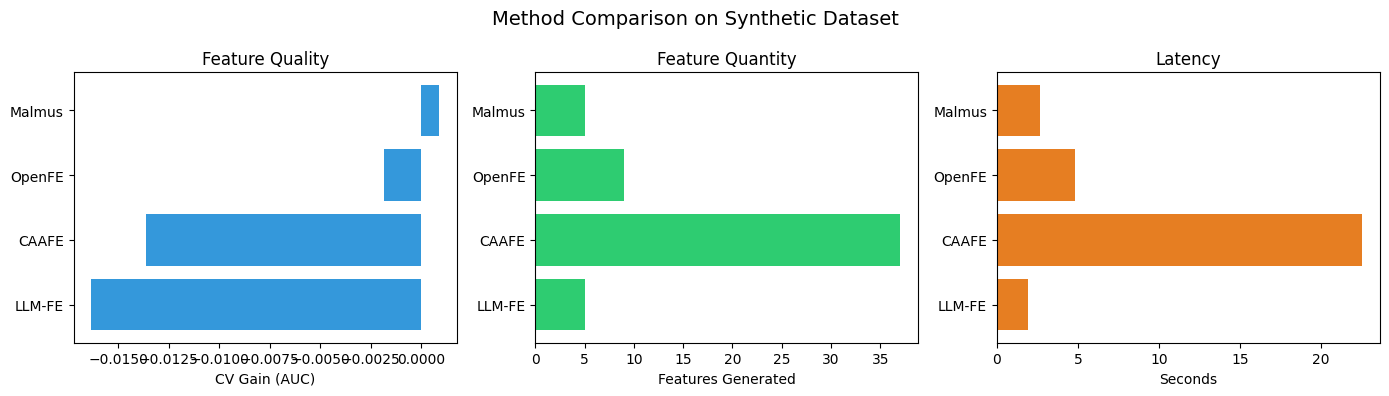

In [10]:
all_results = [r for r in [ofe_results, caafe_results, llmfe_results, malmus_results] if r is not None]

if all_results:
    df = pd.DataFrame(all_results).sort_values('gain', ascending=True)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].barh(df['method'], df['gain'], color='#3498db')
    axes[0].set_xlabel('CV Gain (AUC)')
    axes[0].set_title('Feature Quality')

    axes[1].barh(df['method'], df['n_features'], color='#2ecc71')
    axes[1].set_xlabel('Features Generated')
    axes[1].set_title('Feature Quantity')

    axes[2].barh(df['method'], df['latency'], color='#e67e22')
    axes[2].set_xlabel('Seconds')
    axes[2].set_title('Latency')

    plt.suptitle('Method Comparison on Synthetic Dataset', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No method results to compare. Set DEEPSEEK_API_KEY to run LLM methods.')

## Summary

| Method | Best For | LLM Required | Key Trade-off |
|--------|----------|-------------|---------------|
| **MALMAS** | Complex datasets needing diverse feature types | Yes | Most sophisticated but highest latency |
| **CAAFE** | Datasets with rich domain descriptions | Yes | Good domain injection but relies on free-text parsing |
| **LLM-FE** | Iterative improvement with feedback loops | Yes | Evolutionary approach but more API calls |
| **OpenFE** | Quick baseline, no API key needed | No | Strongest non-LLM but limited to operator expansion |
| **Malmus** | Reliable structured output, any provider | Yes | Most reliable parsing but single-method approach |

**Next steps:**
- [03_benchmarks_and_artifacts.ipynb](./03_benchmarks_and_artifacts.ipynb) — Experiment matrix & artifact analysis
- [04_custom_method.ipynb](./04_custom_method.ipynb) — Write your own method